# 03. Evaluation and Insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import confusion_matrix, roc_auc_score

In [2]:
# CONFIG
MODEL_PATH = "../models/churn_xgb_model.pkl" 
X_TEST_PATH = "../data/processed/X_test.csv"
Y_TEST_PATH = "../data/processed/y_test.csv"

In [3]:
# Load data & model
model = joblib.load(MODEL_PATH)
X_test = pd.read_csv(X_TEST_PATH)
y_test = pd.read_csv(Y_TEST_PATH)

In [4]:
# Get probabilities (The risk score)
# We want the probability of being "Retained" (Class 1)
y_probs = model.predict_proba(X_test)[:, 1]

### 🔎 Insight 1: Feature Importance

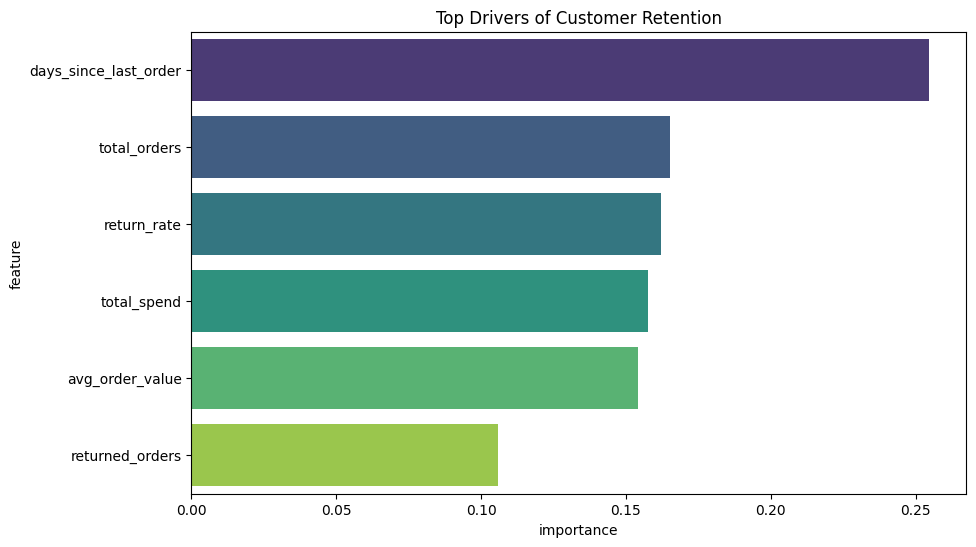

In [5]:
# "What drives retention?"
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature', hue='feature', palette='viridis')
plt.title("Top Drivers of Customer Retention")
plt.show()

### 🔎 Insight 2: The Profit Simulation

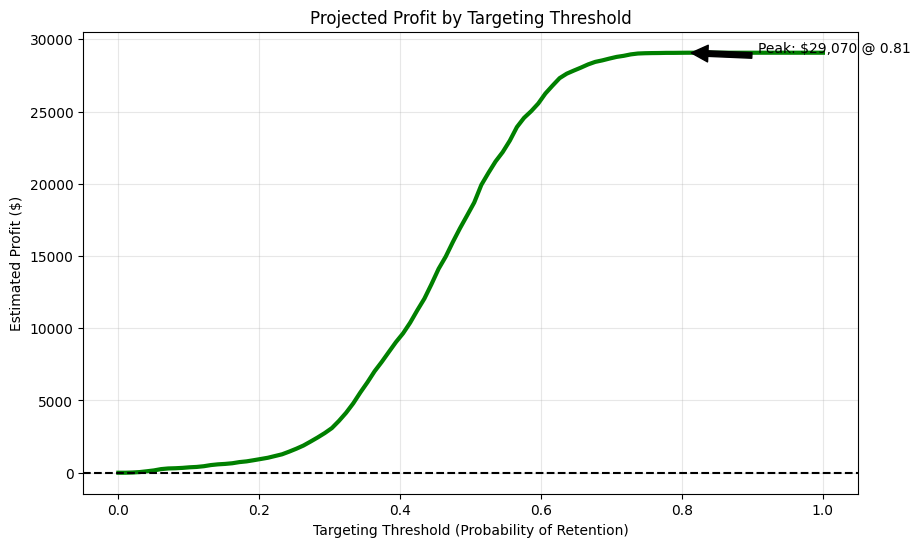

Optimal Strategy: Target customers with < 81% retention probability for maximum profit of $29070.00


In [8]:
# Scenario: 
# - We offer a $5 discount to users we think will churn (Target = 0).
# - If we save them, we gain $50 in CLV (Customer Liftime Value).
# - Success rate: 20%
# - We want to find the optimal targeting threshold to maximize profit.

results = pd.DataFrame({
    'actual_retained': y_test.iloc[:, 0], # 1 = Retained, 0 = Churned
    'retention_prob': y_probs
})

# We target users with low retention probability (High churn risk)
# Let's test different thresholds: "Target everyone below 20% probability", "Below 30%", etc.
thresholds = np.linspace(0, 1, 100)
profits = []

for t in thresholds:
    # Who do we target? (Anyone with probability < t)
    targets = results[results['retention_prob'] < t]
    
    # Costs & gains
    n_campaigns = len(targets)
    cost = n_campaigns * 5 # $5 per coupon
    
    # Assume the campaign saves 20% of the churners we target
    # Real churners in our target list:
    real_churners_targeted = targets[targets['actual_retained'] == 0]
    saved_customers = len(real_churners_targeted) * 0.2
    
    revenue = saved_customers * 50 # $50 CLV gained per saved customer
    
    profit = revenue - cost
    profits.append(profit)
    

# Plot the Curve
plt.figure(figsize=(10, 6))
plt.plot(thresholds, profits, color='green', linewidth=3)
plt.axhline(0, color='black', linestyle='--')
plt.title("Projected Profit by Targeting Threshold")
plt.xlabel("Targeting Threshold (Probability of Retention)")
plt.ylabel("Estimated Profit ($)")

# Find peak profit point
max_profit = max(profits)
optimal_threshold = thresholds[np.argmax(profits)]

plt.annotate(f'Peak: ${max_profit:,.0f} @ {optimal_threshold:.2f}', 
             xy=(optimal_threshold, max_profit), 
             xytext=(optimal_threshold+0.1, max_profit),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.grid(True, alpha=0.3)
plt.show()

print(f"Optimal Strategy: Target customers with < {optimal_threshold:.0%} retention probability for maximum profit of ${max_profit:.2f}")